In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import itertools
import time
from joblib import Parallel, delayed

In [2]:
import yfinance as yf
import pandas as pd

def fetch_turtle_universe():
    print("🌍 Initialisation du téléchargement de l'univers Turtle...")
    
    # 1. Sélection des Tickers (Le panier macro-économique)
    turtle_assets = {
        'Commodities': ['GC=F', 'CL=F', 'SI=F', 'HG=F', 'ZC=F'], # Or, Pétrole Brut, Argent, Cuivre, Maïs
        'Forex': ['EURUSD=X', 'USDJPY=X', 'GBPUSD=X'],           # Euro, Yen, Livre Sterling                                # Bons du Trésor US 20+ ans et 7-10 ans
        'Crypto': ['BTC-USD', 'ETH-USD'], 
        'Indice': ['^GSPC']                        # Bitcoin, Ethereum
    }
    
    # Aplatissement du dictionnaire en une seule liste de tickers
    tickers = [ticker for category in turtle_assets.values() for ticker in category]
    
    # 2. Téléchargement depuis Yahoo Finance (Historique long)
    print(f"📥 Téléchargement de {len(tickers)} actifs depuis 1900...")
    raw_data = yf.download(tickers, start="1900-01-01", interval='1d', progress=True)
    
    # 3. Transformation des données (Wide to Long Format)
    print("⚙️ Restructuration du DataFrame pour l'algorithme...")
    
    # yfinance renvoie un MultiIndex. On "empile" (stack) le niveau des Tickers pour en faire une colonne
    # Le level=1 correspond généralement aux Tickers dans les récentes versions de yfinance
    df = raw_data.stack(level=1, future_stack=True).reset_index()
    
    # 4. Renommage strict pour correspondre à ton algorithme
    # (Attention à la casse des lettres, Pandas ne pardonne pas)
    df = df.rename(columns={
        'Date': 'date',
        'Ticker': 'symbol', # Le nom généré par stack()
        'High': 'high',
        'Low': 'low',
        'Close': 'close',
        'Open': 'open',
        'Volume': 'volume'
    })
    
    # 5. Nettoyage et tri final
    # On s'assure que la date est au bon format
    df['date'] = pd.to_datetime(df['date']).dt.tz_localize(None) 
    
    # Tri par actif puis par date chronologique
    df = df.sort_values(by=['symbol', 'date']).reset_index(drop=True)
    
    # Suppression des jours sans cotation (ex: jours fériés)
    df = df.dropna(subset=['close', 'high', 'low'])
    
    print(f"✅ Terminé ! DataFrame généré avec {len(df)} lignes.")
    return df

# ==========================================
# 🚀 EXÉCUTION
# ==========================================
df = fetch_turtle_universe()

# Vérification visuelle
print("\nAperçu des données prêtes pour le backtest :")
display(df.head())
print("\nListe des actifs disponibles dans df :", df['symbol'].unique())

🌍 Initialisation du téléchargement de l'univers Turtle...
📥 Téléchargement de 11 actifs depuis 1900...


[*********************100%***********************]  11 of 11 completed


⚙️ Restructuration du DataFrame pour l'algorithme...
✅ Terminé ! DataFrame généré avec 83227 lignes.

Aperçu des données prêtes pour le backtest :


Price,date,symbol,close,high,low,open,volume
21942,2014-09-17,BTC-USD,457.334015,468.174011,452.421997,465.864014,21056800.0
21943,2014-09-18,BTC-USD,424.440002,456.859985,413.104004,456.859985,34483200.0
21944,2014-09-19,BTC-USD,394.795990,427.834991,384.532013,424.102997,37919700.0
21945,2014-09-20,BTC-USD,408.903992,423.295990,389.882996,394.673004,36863600.0
21946,2014-09-21,BTC-USD,398.821014,412.425995,393.181000,408.084991,26580100.0



Liste des actifs disponibles dans df : ['BTC-USD' 'CL=F' 'ETH-USD' 'EURUSD=X' 'GBPUSD=X' 'GC=F' 'HG=F' 'SI=F'
 'USDJPY=X' 'ZC=F' '^GSPC']


In [3]:
import numpy as np
import pandas as pd

def generate_mr_signals(
    df,
    bb_window=20,       
    bb_std=2.0,         
    rsi_window=14,
    trend_filter=200,   # 🛡️ LE BOUCLIER : La tendance de fond (MA 200)
    allocation_per_trade=1.0 
):
    required_cols = ['symbol', 'date', 'close']
    data = df[required_cols].copy()
    data = data.sort_values(['symbol', 'date'])

    # 1. Bandes de Bollinger & RSI
    data['SMA'] = data.groupby('symbol')['close'].transform(lambda x: x.rolling(bb_window).mean().shift(1))
    data['STD'] = data.groupby('symbol')['close'].transform(lambda x: x.rolling(bb_window).std().shift(1))
    data['BB_Upper'] = data['SMA'] + (data['STD'] * bb_std)
    data['BB_Lower'] = data['SMA'] - (data['STD'] * bb_std)

    delta = data.groupby('symbol')['close'].diff()
    gain = (delta.where(delta > 0, 0)).fillna(0)
    loss = (-delta.where(delta < 0, 0)).fillna(0)
    avg_gain = gain.groupby(data['symbol']).transform(lambda x: x.ewm(com=rsi_window-1, min_periods=rsi_window).mean())
    avg_loss = loss.groupby(data['symbol']).transform(lambda x: x.ewm(com=rsi_window-1, min_periods=rsi_window).mean())
    rs = avg_gain / avg_loss
    data['RSI'] = 100 - (100 / (1 + rs))
    data['RSI_Prev'] = data.groupby('symbol')['RSI'].shift(1)

    # 2. Le Filtre de Tendance (MA 200)
    data['Trend_MA'] = data.groupby('symbol')['close'].transform(lambda x: x.rolling(trend_filter).mean().shift(1))

    # 3. ⚠️ NOUVELLE LOGIQUE : Mean Reversion Filtré
    # LONG : Panique court terme (BB Low + RSI < 30) MAIS Tendance haussière (Prix > MA 200)
    data['Long_Entry'] = (data['close'] < data['BB_Lower']) & (data['RSI_Prev'] < 30) & (data['close'] > data['Trend_MA'])
    
    # SHORT : Euphorie court terme (BB Up + RSI > 70) MAIS Tendance baissière (Prix < MA 200)
    data['Short_Entry'] = (data['close'] > data['BB_Upper']) & (data['RSI_Prev'] > 70) & (data['close'] < data['Trend_MA'])

    data['Signal'] = np.nan
    data.loc[data['Long_Entry'], 'Signal'] = 1
    data.loc[data['Short_Entry'], 'Signal'] = -1

    data['Current_Pos'] = data.groupby('symbol')['Signal'].ffill().fillna(0)

    # Sortie sur la petite SMA (rapide)
    data.loc[(data['Current_Pos'] == 1) & (data['close'] >= data['SMA']), 'Signal'] = 0
    data.loc[(data['Current_Pos'] == -1) & (data['close'] <= data['SMA']), 'Signal'] = 0

    data['Signal'] = data.groupby('symbol')['Signal'].ffill().fillna(0)

    # Position Sizing
    data['Target_Weight'] = data['Signal'] * allocation_per_trade

    max_leverage = 2.0
    data['Total_Exposure'] = data.groupby('date')['Target_Weight'].transform(lambda x: x.abs().sum())
    
    data['Target_Weight'] = np.where(
        data['Total_Exposure'] > max_leverage,
        data['Target_Weight'] * (max_leverage / data['Total_Exposure']),
        data['Target_Weight']
    )

    data['NextReturn'] = data.groupby('symbol')['close'].shift(-1) / data['close'] - 1
    # On attend que la MA 200 soit calculée pour démarrer
    return data.dropna(subset=['NextReturn', 'Trend_MA'])

In [4]:
# ==========================================
# 2. MOTEUR DE BACKTEST
# ==========================================
def run_vectorized_backtest(data, transaction_cost=0.002): 
    data['Weight_Change'] = data.groupby('symbol')['Target_Weight'].diff().fillna(data['Target_Weight'])
    data['Cost'] = data['Weight_Change'].abs() * transaction_cost
    data['Strat_Return'] = data['Target_Weight'] * data['NextReturn']
    data['is_trade'] = (data['Weight_Change'].abs() > 0.001).astype(int)
    
    port_returns = data.groupby('date')[['Strat_Return', 'Cost', 'is_trade']].sum()
    port_returns['Net_Return'] = port_returns['Strat_Return'] - port_returns['Cost']
    port_returns['Capital'] = (1 + port_returns['Net_Return']).cumprod()
    
    return port_returns

In [5]:
import itertools
import time
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
import pandas as pd

# ==========================================
# 2. MOTEUR DE BACKTEST (AVEC TREND FILTER)
# ==========================================
def run_single_backtest_mr(params, df_source, start_date, end_date):
    # 🛠️ DÉCOMPRESSION DES 5 PARAMÈTRES
    bb_win, bb_s, rsi_win, trend_win, alloc_pct = params

    default_output = {
        "BB_Window": bb_win, "BB_Std": bb_s, "RSI_Window": rsi_win,
        "Trend_Filter": trend_win, "Allocation_Per_Trade": alloc_pct,
        "Total Return": np.nan, "CAGR": np.nan, "Calmar Ratio": np.nan,
        "Max Drawdown": np.nan, "Sharpe Ratio": np.nan, "Error": None
    }

    try:
        df_source = df_source.copy()
        df_source['date'] = pd.to_datetime(df_source['date'])
        
        # On passe le nouveau paramètre trend_filter
        full_signals = generate_mr_signals(
            df_source, bb_window=bb_win, bb_std=bb_s, 
            rsi_window=rsi_win, trend_filter=trend_win, allocation_per_trade=alloc_pct
        )

        mask = (full_signals['date'] >= pd.to_datetime(start_date)) & (full_signals['date'] <= pd.to_datetime(end_date))
        backtest_data = full_signals.loc[mask].copy()

        if backtest_data.empty:
            default_output["Error"] = "No data"
            return default_output

        res_df = run_vectorized_backtest(backtest_data, transaction_cost=0.002)

        final_cap = res_df['Capital'].iloc[-1]
        n_days = (res_df.index[-1] - res_df.index[0]).days
        n_years = n_days / 365.25 if n_days >= 1 else 1.0
        
        cagr = (final_cap ** (1 / n_years)) - 1 if final_cap > 0 else -1.0
        rolling_max = res_df['Capital'].cummax()
        max_dd = ((res_df['Capital'] - rolling_max) / rolling_max).min() if rolling_max.iloc[-1] > 0 else -1.0
        mean_ret = res_df['Net_Return'].mean()
        std_ret = res_df['Net_Return'].std()
        sharpe = (mean_ret / std_ret) * np.sqrt(252) if std_ret > 0 else 0 
        calmar = abs(cagr / max_dd) if max_dd != 0 else 0 

        output = default_output.copy()
        output.update({
            "Total Return": final_cap - 1, "CAGR": cagr,
            "Calmar Ratio": calmar, "Max Drawdown": max_dd, "Sharpe Ratio": sharpe
        })
        return output

    except Exception as e:
        default_output["Error"] = repr(e) 
        return default_output

In [6]:
def grid_search_execution_mr(df, param_grid, start_date, end_date):
    keys, values = zip(*param_grid.items())
    combinations = list(itertools.product(*values)) 

    print(f"🚀 Lancement de la Grid Search Mean Reversion sur {len(combinations)} combinaisons...")
    start_time = time.time()

    results_list = Parallel(n_jobs=-1)(
        delayed(run_single_backtest_mr)(params, df, start_date, end_date) for params in combinations
    )

    end_time = time.time()
    print(f"✅ Terminé en {end_time - start_time:.2f} secondes.")

    results_df = pd.DataFrame(results_list)
    if results_df.empty or 'Error' not in results_df.columns:
        print("⚠️ Attention : Aucun backtest généré.")
        return results_df
    
    best_strats = results_df[results_df['Error'].isna()].sort_values(by='CAGR', ascending=False)
    return best_strats

In [7]:
# ==========================================
# 3. ANALYSE FINALE
# ==========================================
def analyze_best_strategy_mr(best_df, df_source, start_date, end_date):
    if best_df.empty:
        print("❌ Aucune stratégie valide trouvée.")
        return None, None
        
    best_params = best_df.sort_values(by='CAGR', ascending=False).iloc[0]
    
    # 🛠️ Extraction de la MA de tendance
    bb_win = int(best_params['BB_Window'])
    bb_s = float(best_params['BB_Std'])
    rsi_win = int(best_params['RSI_Window'])
    trend_win = int(best_params['Trend_Filter']) 
    alloc_pct = float(best_params['Allocation_Per_Trade']) 
    
    print("\n🏆 --- RECALCUL DE LA MEILLEURE STRATÉGIE MEAN REVERSION ---")
    print(f"Bollinger: {bb_win}j | Écart-Type: {bb_s} | RSI: {rsi_win}j | Filtre Tendance: MA {trend_win} | Allocation: {alloc_pct*100:.0f}%")
    
    full_signals = generate_mr_signals(
        df_source, bb_window=bb_win, bb_std=bb_s, 
        rsi_window=rsi_win, trend_filter=trend_win, allocation_per_trade=alloc_pct
    )
    
    mask = (full_signals['date'] >= pd.to_datetime(start_date)) & (full_signals['date'] <= pd.to_datetime(end_date))
    backtest_data = full_signals.loc[mask].copy()
    res_df = run_vectorized_backtest(backtest_data, transaction_cost=0.002)
    
    try:
        gspc_data = yf.download('^GSPC', start=start_date, end=end_date, interval='1d', progress=False)
        gspc_close = gspc_data['Close']['^GSPC'] if isinstance(gspc_data.columns, pd.MultiIndex) else gspc_data['Close']
        gspc_close.index = pd.to_datetime(gspc_close.index).tz_localize(None)
        
        aligned_gspc = pd.DataFrame(index=pd.to_datetime(res_df.index).tz_localize(None))
        aligned_gspc['GSPC_Price'] = gspc_close.reindex(aligned_gspc.index, method='ffill').bfill()
        res_df['GSPC_Capital'] = aligned_gspc['GSPC_Price'] / aligned_gspc['GSPC_Price'].iloc[0]
    except:
        res_df['GSPC_Capital'] = 1.0 

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})
    
    ax1.plot(res_df.index, res_df['Capital'], color='darkorange', linewidth=2.5, 
             label=f"Mean Reversion (CAGR: {best_params['CAGR']*100:.1f}%, MaxDD: {best_params['Max Drawdown']*100:.1f}%)")
    ax1.plot(res_df.index, res_df['GSPC_Capital'], color='dimgray', linewidth=1.5, linestyle='--', label="S&P 500 (^GSPC)")
    ax1.set_yscale('log')
    ax1.set_title("Évolution du Capital - Stratégie Mean Reversion Filtrée", fontsize=14, fontweight='bold')
    ax1.grid(True, which="both", ls="--", alpha=0.4)
    ax1.legend(loc='upper left', fontsize=12)
    
    ax2.bar(res_df.index, res_df['is_trade'], color='purple', width=3, alpha=0.5, label='Transactions (Allers-Retours rapides)')
    ax2.set_title("Activité de Trading", fontsize=12)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    return res_df, backtest_data

🚀 Lancement de la Grid Search Mean Reversion sur 600 combinaisons...


/opt/homebrew/Caskroom/miniforge/base/envs/ml-prod-v2/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


✅ Terminé en 75.52 secondes.


,BB_Window,BB_Std,RSI_Window,Trend_Filter,Allocation_Per_Trade,Total Return,CAGR,Calmar Ratio,Max Drawdown,Sharpe Ratio,Error
198,20,3.5,5,150,1.0,4.495927,0.067190,0.142264,-0.472288,0.408904,None
54,10,3.0,5,150,1.0,3.792401,0.061626,0.100803,-0.611349,0.349768,None
174,20,3.0,5,150,1.0,3.492444,0.059010,0.097542,-0.604971,0.322054,None
199,20,3.5,5,200,1.0,2.717088,0.051381,0.123927,-0.414607,0.318695,None
53,10,3.0,5,100,1.0,1.978305,0.042528,0.086719,-0.490409,0.292061,None



🏆 --- RECALCUL DE LA MEILLEURE STRATÉGIE MEAN REVERSION ---
Bollinger: 20j | Écart-Type: 3.5 | RSI: 5j | Filtre Tendance: MA 150 | Allocation: 100%


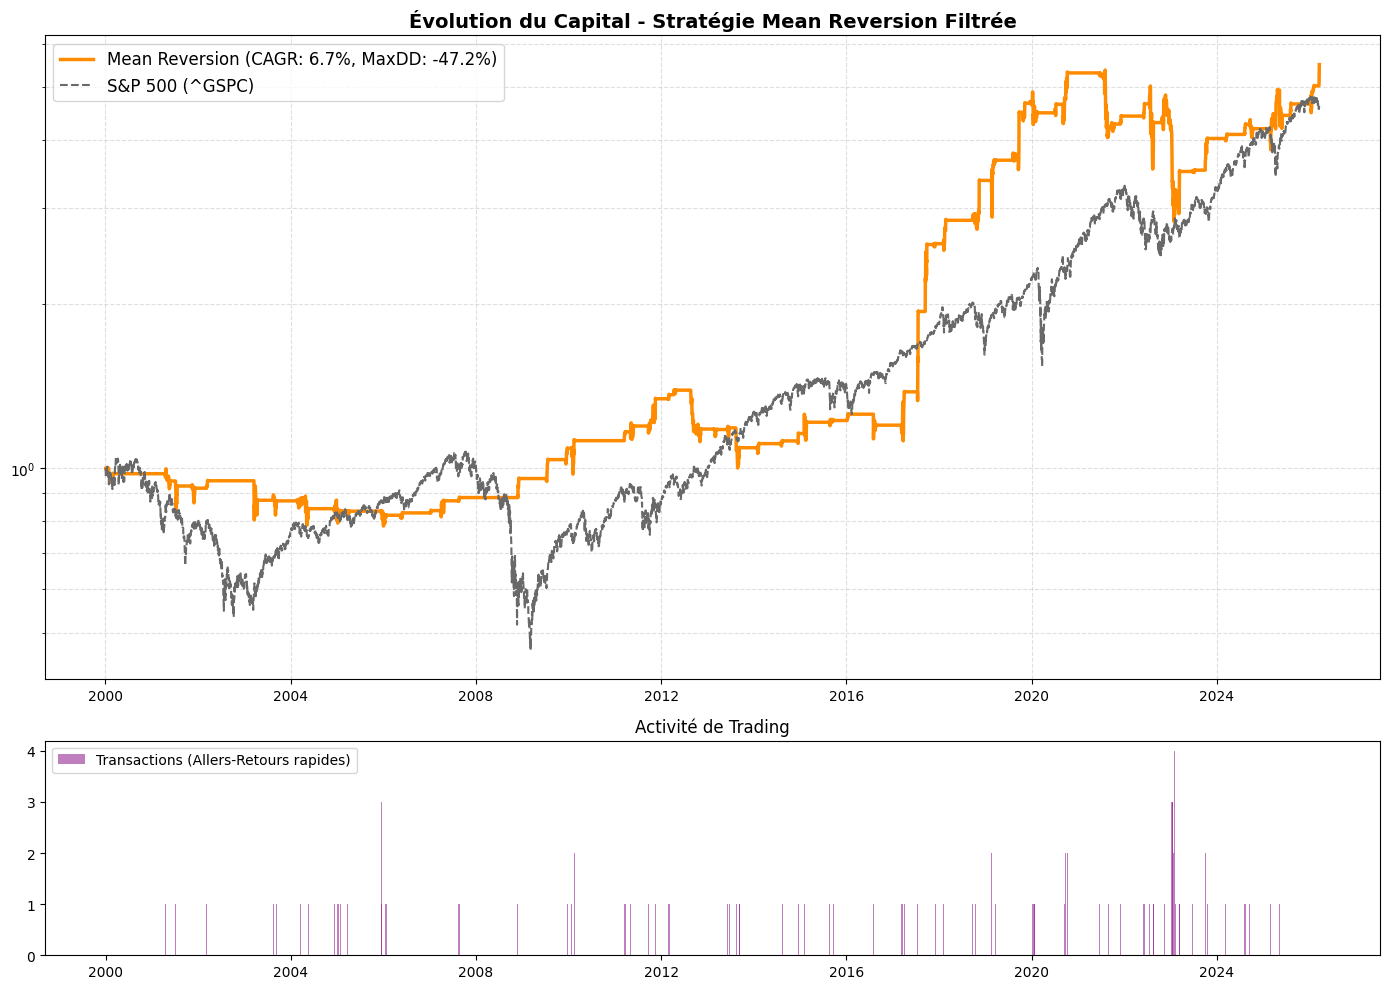

In [17]:
param_grid_mr = {
    'bb_window': [10, 20, 30, 40, 50],              
    'bb_std': [2.0, 2.5, 3, 3.5, 4],              
    'rsi_window': [0, 5, 10, 14, 25, 30],
    'trend_filter': [50, 100, 150, 200],         # 🛡️ Test de la Tendance (Moyenne, Longue, Très Longue)
    'allocation_per_trade': [1.0]            # On reste "All-In" sans levier
}

# 🚀 Lancement !
best_mr_strats = grid_search_execution_mr(df, param_grid_mr, start_date='2000-01-01', end_date='2026-03-18')

display(best_mr_strats.head(5))

# Analyse finale
stats, trades = analyze_best_strategy_mr(best_mr_strats, df, start_date='2000-01-01', end_date='2026-03-18')

In [9]:
all_trades_history[all_trades_history['Signal']!=0].sort_values(by=['date'], ascending=False)

NameError: name 'all_trades_history' is not defined